<a href="https://colab.research.google.com/github/debrupa03/Development-of-Interactive-Cyber-Threat-Visualization-Dashboard/blob/main/E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Generate E-commerce Data (20 rows, 10 columns)
ecommerce_data = {
    'Order_ID': range(101, 121),
    'Customer_ID': [f'CUST_{i}' for i in range(1, 21)],
    'Product_Category': np.random.choice(['Electronics', 'Apparel', 'Home', 'Beauty'], 20),
    'Order_Value': np.random.uniform(20.0, 500.0, 20).round(2),
    'Quantity': np.random.randint(1, 6, 20),
    'Discount_Applied': np.random.choice([0, 5, 10, 15], 20),
    'Payment_Method': np.random.choice(['Credit Card', 'PayPal', 'Debit Card'], 20),
    'Shipping_Cost': np.random.uniform(5.0, 25.0, 20).round(2),
    'Return_Status': np.random.choice(['No', 'Yes'], 20, p=[0.8, 0.2]),
    'Days_to_Ship': np.random.randint(1, 7, 20)
}

df_retail = pd.DataFrame(ecommerce_data)
print("E-commerce Dataset Sample:")
print(df_retail.head())

E-commerce Dataset Sample:
   Order_ID Customer_ID Product_Category  Order_Value  Quantity  \
0       101      CUST_1          Apparel       228.45         3   
1       102      CUST_2             Home       265.68         5   
2       103      CUST_3      Electronics       439.07         2   
3       104      CUST_4           Beauty       233.76         1   
4       105      CUST_5          Apparel        49.22         3   

   Discount_Applied Payment_Method  Shipping_Cost Return_Status  Days_to_Ship  
0                10    Credit Card          13.59            No             1  
1                10     Debit Card          12.34            No             5  
2                10    Credit Card          12.52            No             4  
3                10     Debit Card          11.89            No             2  
4                10    Credit Card           5.01            No             2  


In [4]:
df_retail['Net_Revenue'] = df_retail['Order_Value'] - (df_retail['Order_Value'] * df_retail['Discount_Applied'] / 100) + df_retail['Shipping_Cost']
display(df_retail.head())

,Order_ID,Customer_ID,Product_Category,Order_Value,Quantity,Discount_Applied,Payment_Method,Shipping_Cost,Return_Status,Days_to_Ship,Net_Revenue
0,101,CUST_1,Apparel,228.45,3,10,Credit Card,13.59,No,1,219.195
1,102,CUST_2,Home,265.68,5,10,Debit Card,12.34,No,5,251.452
2,103,CUST_3,Electronics,439.07,2,10,Credit Card,12.52,No,4,407.683
3,104,CUST_4,Beauty,233.76,1,10,Debit Card,11.89,No,2,222.274
4,105,CUST_5,Apparel,49.22,3,10,Credit Card,5.01,No,2,49.308


/tmp/ipython-input-4189287546.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Net_Revenue', data=revenue_by_category, palette='viridis')


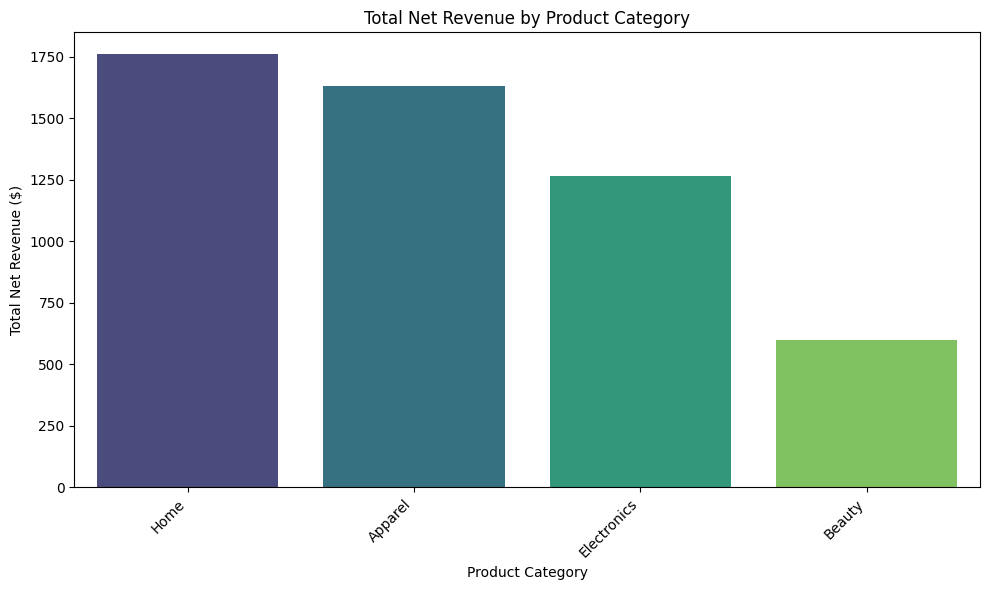

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Product_Category', y='Net_Revenue', data=revenue_by_category, palette='viridis')
plt.title('Total Net Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Net Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Identify the most popular payment method
popular_payment_method = df_retail['Payment_Method'].value_counts().reset_index()
popular_payment_method.columns = ['Payment_Method', 'Number_of_Orders']
display(popular_payment_method)

,Payment_Method,Number_of_Orders
0,Credit Card,9
1,Debit Card,7
2,PayPal,4


In [8]:
# Calculate average Order_Value by Payment_Method
average_order_value_by_payment = df_retail.groupby('Payment_Method')['Order_Value'].mean().reset_index()
average_order_value_by_payment = average_order_value_by_payment.sort_values(by='Order_Value', ascending=False)
display(average_order_value_by_payment)

,Payment_Method,Order_Value
0,Credit Card,303.840000
1,Debit Card,263.117143
2,PayPal,218.455000


In [6]:
average_order_value = df_retail['Order_Value'].mean()
print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $272.51


In [5]:
revenue_by_category = df_retail.groupby('Product_Category')['Net_Revenue'].sum().reset_index()
revenue_by_category = revenue_by_category.sort_values(by='Net_Revenue', ascending=False)
display(revenue_by_category)

,Product_Category,Net_Revenue
3,Home,1760.5395
0,Apparel,1628.6090
2,Electronics,1265.3405
1,Beauty,596.6485


To identify customers who only shop in specific categories, we'll first count the number of unique product categories each customer has purchased from. Then, we'll filter for customers who have bought from only one distinct category.

In [11]:
# Calculate the number of unique product categories for each customer
customer_category_counts = df_retail.groupby('Customer_ID')['Product_Category'].nunique().reset_index()
customer_category_counts.rename(columns={'Product_Category': 'Unique_Categories_Count'}, inplace=True)

# Identify customers who shop in only one category
customers_single_category = customer_category_counts[customer_category_counts['Unique_Categories_Count'] == 1]

# Get the actual categories for these customers
# Merge back with the original dataframe to find the specific category
single_category_customers_details = pd.merge(customers_single_category, df_retail, on='Customer_ID', how='inner')
single_category_customers_details = single_category_customers_details[['Customer_ID', 'Product_Category']].drop_duplicates()

print("Customers who shop in only one specific category:")
display(single_category_customers_details)

Customers who shop in only one specific category:


,Customer_ID,Product_Category
0,CUST_1,Apparel
1,CUST_10,Apparel
2,CUST_11,Home
3,CUST_12,Apparel
4,CUST_13,Beauty
5,CUST_14,Electronics
6,CUST_15,Electronics
7,CUST_16,Apparel
8,CUST_17,Home
9,CUST_18,Electronics


To analyze discount efficiency, we'll examine two key aspects:

1.  **Discount vs. Quantity Sold**: Does offering a higher discount lead to more items being purchased per order?
2.  **Discount vs. Net Revenue**: How does the discount affect the actual net revenue generated per order? This helps determine if discounts are hurting profit margins.

In [12]:
# 1. Analyze Discount vs. Quantity Sold
discount_quantity_analysis = df_retail.groupby('Discount_Applied')['Quantity'].mean().reset_index()
discount_quantity_analysis.rename(columns={'Quantity': 'Average_Quantity_Sold'}, inplace=True)
print("\nAverage Quantity Sold by Discount Level:")
display(discount_quantity_analysis.sort_values(by='Discount_Applied', ascending=True))


Average Quantity Sold by Discount Level:


,Discount_Applied,Average_Quantity_Sold
0,0,2.500000
1,5,2.250000
2,10,3.333333
3,15,2.800000


In [13]:
# 2. Analyze Discount vs. Net Revenue
discount_revenue_analysis = df_retail.groupby('Discount_Applied')['Net_Revenue'].mean().reset_index()
discount_revenue_analysis.rename(columns={'Net_Revenue': 'Average_Net_Revenue_per_Order'}, inplace=True)
print("\nAverage Net Revenue per Order by Discount Level:")
display(discount_revenue_analysis.sort_values(by='Discount_Applied', ascending=True))


Average Net Revenue per Order by Discount Level:


,Discount_Applied,Average_Net_Revenue_per_Order
0,0,345.870000
1,5,298.529125
2,10,249.653889
3,15,223.679200


In [14]:
avg_days_to_ship_by_return_status = df_retail.groupby('Return_Status')['Days_to_Ship'].mean().reset_index()
print("\nAverage Days to Ship by Return Status:")
display(avg_days_to_ship_by_return_status)


Average Days to Ship by Return Status:


,Return_Status,Days_to_Ship
0,No,3.0625
1,Yes,3.2500


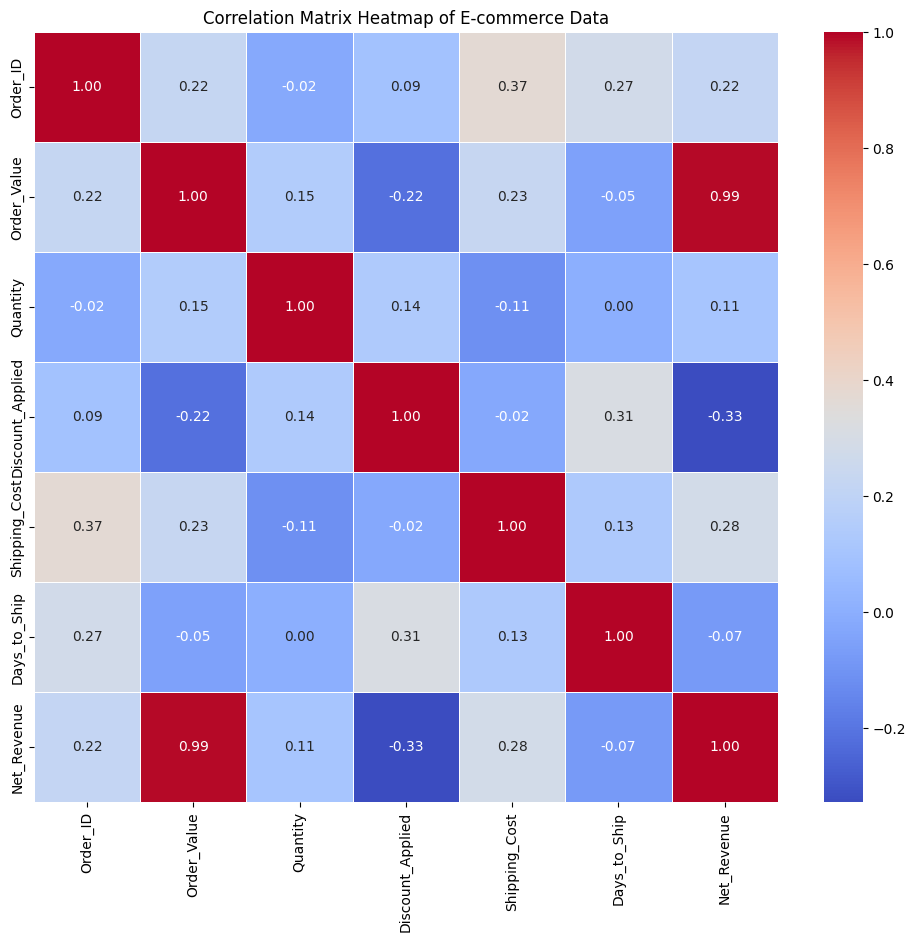

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df_retail.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap of E-commerce Data')
plt.show()

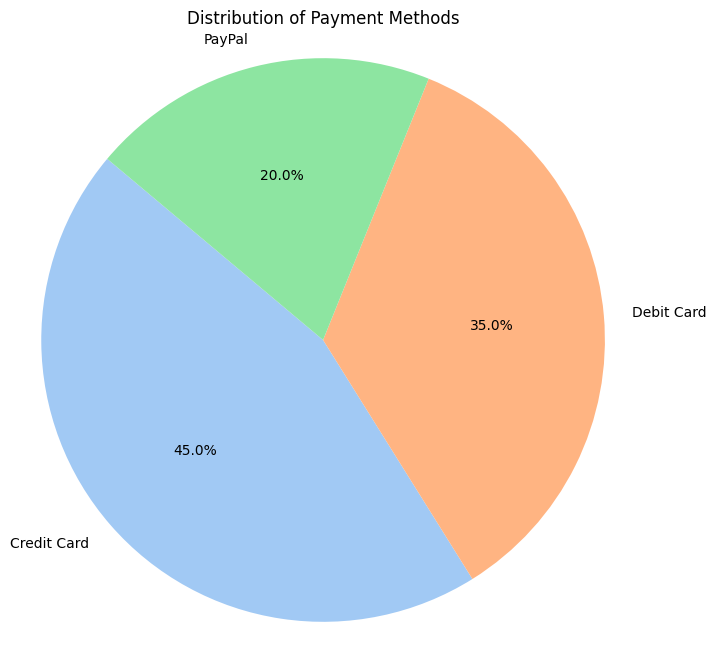

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(popular_payment_method['Number_of_Orders'], labels=popular_payment_method['Payment_Method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Payment Methods')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()